# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Define Dataset Path & Basic Checks

In [ ]:
# PART 2: Define Dataset Path & Verify Structure

import os

DATASET_PATH = "/content/drive/MyDrive/malware_project/final_dataset"

# Verify dataset path
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("❌ Dataset path not found!")

print("✅ Dataset path found:", DATASET_PATH)

# List top-level class folders
class_folders = sorted(os.listdir(DATASET_PATH))
print("\nNumber of classes found:", len(class_folders))
print("Sample class folders:", class_folders[:5])


✅ Dataset path found: /content/drive/MyDrive/malware_project/final_dataset

Number of classes found: 29
Sample class folders: ['benign_dll', 'benign_exe', 'benign_mui', 'benign_other', 'malware_adialerc']


# Define Training Parameters (Image size, batch size, number of classes)

In [ ]:
# PART 3: Define Training Parameters

IMG_SIZE = 224        # Required for MobileNetV2 & ViT
BATCH_SIZE = 32       # Standard batch size
NUM_CLASSES = 29      # 4 benign + 25 malware families

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)


Image size: 224
Batch size: 32
Number of classes: 29


# Create ImageDataGenerator (Normalization & Split)

In [ ]:
# PART 4: Create ImageDataGenerator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,      # Normalize pixels to [0,1]
    validation_split=0.2
)

print("✔ ImageDataGenerator created")


✔ ImageDataGenerator created


# Create Training & Validation Generators

In [ ]:
# PART 5: Create Training Data Generator

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # Multi-class
    color_mode="rgb",
    subset="training",
    shuffle=True
)

print("✔ Training data generator ready")


Found 15379 images belonging to 29 classes.
✔ Training data generator ready


In [ ]:
# PART 6: Create Validation Data Generator

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    subset="validation",
    shuffle=False
)

print("✔ Validation data generator ready")


Found 3830 images belonging to 29 classes.
✔ Validation data generator ready


# Compute class_weight
🎯 Purpose

Handle class imbalance

Prevent model bias toward large classes

Improve recall for rare malware families

Used in ALL models (CNN, MobileNetV2, ViT)

In [ ]:
# PART 7: Compute class_weight

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get class labels from training data
y_train = train_data.classes

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format required by Keras
class_weight_dict = {
    i: weight for i, weight in enumerate(class_weights)
}

print("✔ Class weights computed\n")

for cls, weight in class_weight_dict.items():
    print(f"Class {cls:2d} weight -> {weight:.4f}")


✔ Class weights computed

Class  0 weight -> 0.0677
Class  1 weight -> 88.3851
Class  2 weight -> 8.8385
Class  3 weight -> 132.5776
Class  4 weight -> 5.4113
Class  5 weight -> 5.7023
Class  6 weight -> 0.2247
Class  7 weight -> 0.4166
Class  8 weight -> 3.3353
Class  9 weight -> 6.2389
Class 10 weight -> 3.3144
Class 11 weight -> 4.5326
Class 12 weight -> 3.7346
Class 13 weight -> 4.0793
Class 14 weight -> 1.7387
Class 15 weight -> 1.5371
Class 16 weight -> 3.1012
Class 17 weight -> 3.5832
Class 18 weight -> 5.3567
Class 19 weight -> 4.1430
Class 20 weight -> 4.8652
Class 21 weight -> 4.6518
Class 22 weight -> 4.1757
Class 23 weight -> 8.2861
Class 24 weight -> 5.1486
Class 25 weight -> 5.0029
Class 26 weight -> 1.6217
Class 27 weight -> 6.7989
Class 28 weight -> 0.8286


# Baseline CNN Model Definition

In [ ]:
# PART 8: Define Baseline CNN Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,252,125 (84.89 MB)

 Trainable params: 22,252,125 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

# Train Baseline CNN (WITH class_weight)

In [ ]:
# PART 9: Train Baseline CNN

history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 5658s 12s/step - accuracy: 0.3345 - loss: 2.4404 - val_accuracy: 0.4919 - val_loss: 2.2304
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.5113 - loss: 1.6833 - val_accuracy: 0.5963 - val_loss: 1.3244
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.5905 - loss: 1.0197 - val_accuracy: 0.8334 - val_loss: 0.5769
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.6884 - loss: 0.8312 - val_accuracy: 0.7426 - val_loss: 0.7586
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 76s 158ms/step - accuracy: 0.7111 - loss: 0.6872 - val_accuracy: 0.6206 - val_loss: 1.1741
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 152ms/step - accuracy: 0.6575 - loss: 0.8398 - val_accuracy: 0.7081 - val_loss: 0.8458
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 74s 154ms/step - accuracy: 0.7110 - loss: 0.7861 - val_accuracy: 0.8044 - val_loss: 0.6110
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 72s 149ms/step - accuracy: 0.6798 - loss: 0

# Save Baseline CNN Model

In [ ]:
# PART 10: Save Baseline CNN Model

cnn_model.save("/content/drive/MyDrive/malware_project/models/baseline_cnn.h5")
print("✔ Baseline CNN model saved")


✔ Baseline CNN model saved


# MobileNetV2 Model Definition (Transfer Learning)

In [ ]:
# PART 11: Define MobileNetV2 Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train MobileNetV2 (WITH class_weight)

In [ ]:
# PART 12: Train MobileNetV2

history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    class_weight=class_weight_dict
)


Epoch 1/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 118s 209ms/step - accuracy: 0.5029 - loss: 1.4847 - val_accuracy: 0.7992 - val_loss: 0.7184
Epoch 2/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 74s 155ms/step - accuracy: 0.8373 - loss: 0.2727 - val_accuracy: 0.8916 - val_loss: 0.4411
Epoch 3/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 74s 154ms/step - accuracy: 0.8610 - loss: 0.2532 - val_accuracy: 0.8984 - val_loss: 0.2871
Epoch 4/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 72s 150ms/step - accuracy: 0.8920 - loss: 0.2116 - val_accuracy: 0.8982 - val_loss: 0.3222
Epoch 5/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 74s 153ms/step - accuracy: 0.9131 - loss: 0.1453 - val_accuracy: 0.9227 - val_loss: 0.1930
Epoch 6/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 72s 149ms/step - accuracy: 0.9265 - loss: 0.1323 - val_accuracy: 0.9627 - val_loss: 0.1349
Epoch 7/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.9456 - loss: 0.1074 - val_accuracy: 0.9692 - val_loss: 0.1427
Epoch 8/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 72s 150ms/step - accuracy: 0.9525 - loss: 

# Fine-Tune MobileNetV2

In [ ]:
# PART 13: Fine-Tune MobileNetV2

for layer in base_model.layers[-20:]:
    layer.trainable = True

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet_ft = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    class_weight=class_weight_dict
)


Epoch 1/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 104s 186ms/step - accuracy: 0.6091 - loss: 8.7938 - val_accuracy: 0.9689 - val_loss: 0.1180
Epoch 2/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 151ms/step - accuracy: 0.8683 - loss: 0.8095 - val_accuracy: 0.9642 - val_loss: 0.1141
Epoch 3/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 152ms/step - accuracy: 0.8771 - loss: 0.3294 - val_accuracy: 0.9653 - val_loss: 0.1274
Epoch 4/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 74s 153ms/step - accuracy: 0.8779 - loss: 0.2460 - val_accuracy: 0.9642 - val_loss: 0.1362
Epoch 5/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 73s 152ms/step - accuracy: 0.8913 - loss: 0.1684 - val_accuracy: 0.9708 - val_loss: 0.1271


# Save MobileNetV2 Model

In [ ]:
# PART 14: Save MobileNetV2 Model

mobilenet_model.save("/content/drive/MyDrive/malware_project/models/mobilenetv2_finetuned.h5")
print("✔ MobileNetV2 model saved")


✔ MobileNetV2 model saved


# Vision Transformer (ViT) Model

## Imports (STABLE)

In [ ]:
# PART 15A: Imports (Stable)

import tensorflow as tf
from tensorflow.keras import layers, models
import os



## Build Vision Transformer Model (STABLE)

In [ ]:
def build_vit_model(
    input_shape=(224, 224, 3),
    patch_size=16,
    projection_dim=64,
    transformer_layers=6,   # 🔻 reduced for CPU safety
    num_heads=4,
    transformer_units=[128, 64],
    mlp_head_units=[256],
    num_classes=29
):
    inputs = layers.Input(shape=input_shape)

    # Patch embedding using Conv2D (fast & stable)
    x = layers.Conv2D(
        filters=projection_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid"
    )(inputs)

    x = layers.Reshape((-1, projection_dim))(x)

    # Transformer blocks
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim
        )(x1, x1)

        x2 = layers.Add()([attention, x])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        x3 = layers.Dense(transformer_units[0], activation="gelu")(x3)
        x3 = layers.Dense(transformer_units[1])(x3)

        x = layers.Add()([x3, x2])

    # Pool tokens → FIXES None shape issue
    x = layers.GlobalAveragePooling1D()(x)

    # MLP Head
    for units in mlp_head_units:
        x = layers.Dense(units, activation="relu")(x)
        x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model


## Build & Compile ViT

In [ ]:
vit_model = build_vit_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,216 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 64)   │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 64)   │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ dense_3[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 572,509 (2.18 MB)

 Trainable params: 572,509 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

## CHECKPOINTS

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/malware_project/models/vit_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


## Save EVERY epoch

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR + "/vit_epoch_{epoch:02d}.h5",
    save_weights_only=False,
    save_best_only=False,
    verbose=1
)

earlystop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)


## TRAIN ViT

In [ ]:
vit_history = vit_model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0580 - loss: 3.5749
Epoch 1: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_01.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 4785s 10s/step - accuracy: 0.0580 - loss: 3.5744 - val_accuracy: 0.0316 - val_loss: 2.9032
Epoch 2/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1294 - loss: 2.6098
Epoch 2: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_02.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1145s 2s/step - accuracy: 0.1294 - loss: 2.6101 - val_accuracy: 0.1426 - val_loss: 2.6281
Epoch 3/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1609 - loss: 2.2733
Epoch 3: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_03.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1182s 2s/step - accuracy: 0.1609 - loss: 2.2733 - val_accuracy: 0.2997 - val_loss: 2.3470
Epoch 4/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2280 - loss: 1.7632
Epoch 4: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_04.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1148s 2s/step - accuracy: 0.2280 - loss: 1.7634 - val_accuracy: 0.2533 - val_loss: 2.3398
Epoch 5/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2577 - loss: 1.6530
Epoch 5: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_05.h5


...

481/481 ━━━━━━━━━━━━━━━━━━━━ 1161s 2s/step - accuracy: 0.3116 - loss: 1.1221 - val_accuracy: 0.4102 - val_loss: 1.7110
Epoch 9/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3757 - loss: 0.8912
Epoch 9: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_09.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1153s 2s/step - accuracy: 0.3757 - loss: 0.8912 - val_accuracy: 0.5235 - val_loss: 1.3435
Epoch 10/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3864 - loss: 0.7615
Epoch 10: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_10.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1157s 2s/step - accuracy: 0.3864 - loss: 0.7616 - val_accuracy: 0.4068 - val_loss: 1.4741
Epoch 11/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4119 - loss: 0.6811
Epoch 11: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_11.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1146s 2s/step - accuracy: 0.4120 - loss: 0.6812 - val_accuracy: 0.3922 - val_loss: 1.4613
Epoch 12/12
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4543 - loss: 0.5559
Epoch 12: saving model to /content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_12.h5


481/481 ━━━━━━━━━━━━━━━━━━━━ 1156s 2s/step - accuracy: 0.4543 - loss: 0.5561 - val_accuracy: 0.5021 - val_loss: 1.4284


## (OPTIONAL) RESUME IF CRASHED

In [ ]:
from tensorflow.keras.models import load_model

vit_model = load_model(
    "/content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_03.h5"
)

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_cb]
)


# Save FINAL ViT Model (OFFICIAL)

In [ ]:
# PART 16A: Save FINAL ViT model (recommended format)

FINAL_VIT_PATH = "/content/drive/MyDrive/malware_project/models/vit_final.keras"

vit_model.save(FINAL_VIT_PATH)

print("✅ Final ViT model saved at:", FINAL_VIT_PATH)


✅ Final ViT model saved at: /content/drive/MyDrive/malware_project/models/vit_final.keras


# Imports for Evaluation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Validation Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_eval = ImageDataGenerator(rescale=1./255)

val_data_eval = datagen_eval.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(val_data_eval.class_indices.keys())


Found 19209 images belonging to 29 classes.


# Load Trained Models

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model(
    "/content/drive/MyDrive/malware_project/models/baseline_cnn.h5"
)

mobilenet_model = load_model(
    "/content/drive/MyDrive/malware_project/models/mobilenetv2_finetuned.h5"
)

vit_model = load_model(
    "/content/drive/MyDrive/malware_project/models/vit_checkpoints/vit_epoch_12.h5",
    compile=False
)

print("✔ All models loaded successfully")


✔ All models loaded successfully


In [ ]:
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✔ ViT model compiled successfully")


✔ ViT model compiled successfully


# Prediction Function (Reusable)

In [ ]:
def evaluate_model(model, model_name):
    print(f"\n===== {model_name} =====")

    # Predictions
    y_pred = model.predict(val_data_eval)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = val_data_eval.classes

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, fmt="d")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


# Evaluate All Models


===== Baseline CNN =====
601/601 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step

Classification Report:
                       precision    recall  f1-score   support

           benign_dll       0.99      0.63      0.77      9784
           benign_exe       0.04      0.86      0.07         7
           benign_mui       0.44      0.73      0.55        75
         benign_other       0.03      1.00      0.06         4
     malware_adialerc       0.98      1.00      0.99       122
     malware_agentfyi       0.96      0.97      0.97       116
     malware_allaplea       0.88      0.99      0.93      2949
     malware_allaplel       0.94      0.93      0.94      1591
 malware_aluerongen!j       0.76      1.00      0.87       198
     malware_autorunk       0.12      1.00      0.21       106
   malware_c2lopgen!g       0.39      0.90      0.54       200
       malware_c2lopp       0.21      0.72      0.33       146
malware_dialplatformb       1.00      1.00      1.00       177
     malware_dontovoa    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


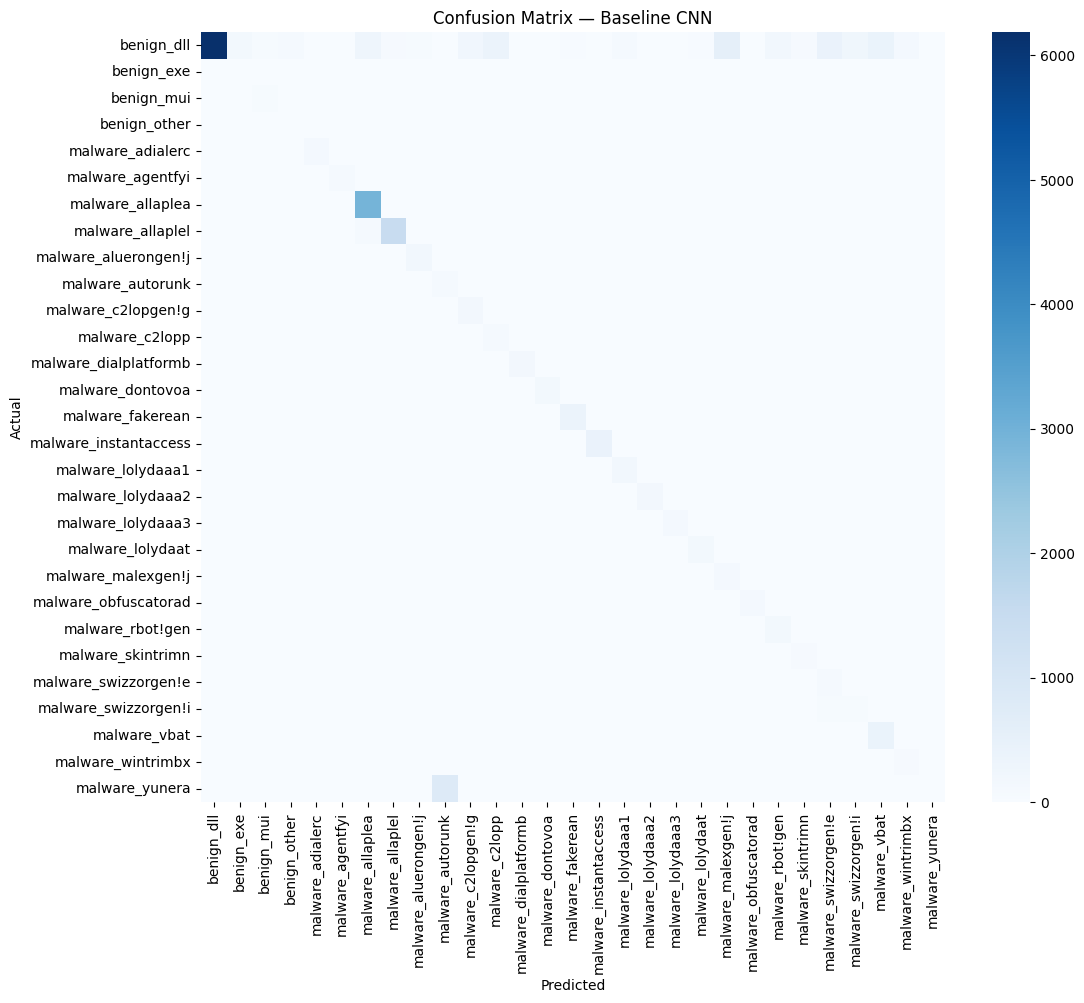


===== MobileNetV2 =====
601/601 ━━━━━━━━━━━━━━━━━━━━ 800s 1s/step

Classification Report:
                       precision    recall  f1-score   support

           benign_dll       1.00      0.95      0.97      9784
           benign_exe       0.05      0.86      0.10         7
           benign_mui       0.37      0.87      0.52        75
         benign_other       0.15      1.00      0.27         4
     malware_adialerc       1.00      1.00      1.00       122
     malware_agentfyi       0.86      0.99      0.92       116
     malware_allaplea       0.98      0.98      0.98      2949
     malware_allaplel       0.96      1.00      0.98      1591
 malware_aluerongen!j       1.00      1.00      1.00       198
     malware_autorunk       1.00      1.00      1.00       106
   malware_c2lopgen!g       0.85      0.97      0.91       200
       malware_c2lopp       0.74      0.95      0.83       146
malware_dialplatformb       1.00      1.00      1.00       177
     malware_dontovoa     

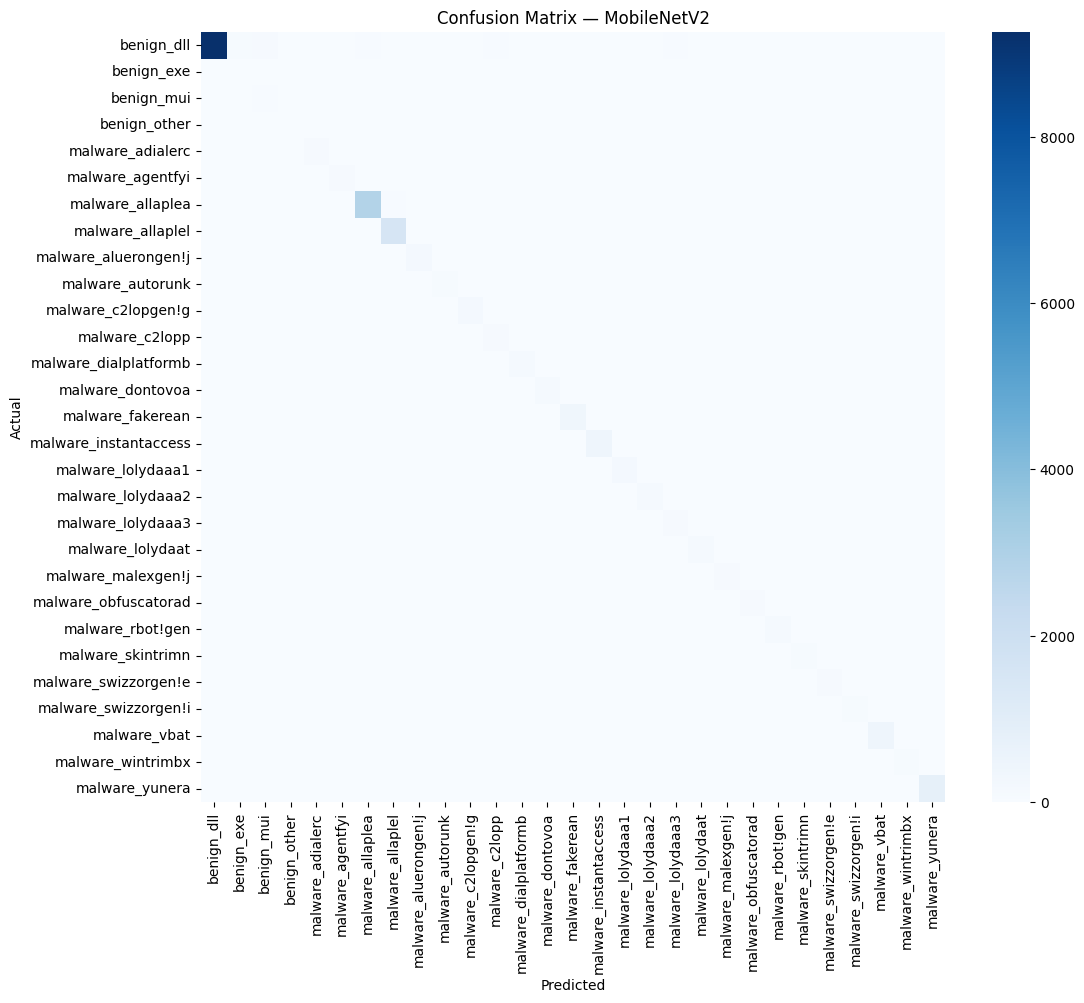


===== Vision Transformer (ViT) =====
601/601 ━━━━━━━━━━━━━━━━━━━━ 537s 892ms/step

Classification Report:
                       precision    recall  f1-score   support

           benign_dll       0.99      0.22      0.35      9784
           benign_exe       0.01      0.57      0.02         7
           benign_mui       0.00      0.00      0.00        75
         benign_other       0.01      1.00      0.03         4
     malware_adialerc       0.38      1.00      0.55       122
     malware_agentfyi       0.98      0.97      0.98       116
     malware_allaplea       0.99      0.57      0.73      2949
     malware_allaplel       0.57      0.98      0.73      1591
 malware_aluerongen!j       0.96      0.91      0.94       198
     malware_autorunk       0.00      0.00      0.00       106
   malware_c2lopgen!g       0.27      0.83      0.41       200
       malware_c2lopp       0.12      0.68      0.20       146
malware_dialplatformb       0.99      0.99      0.99       177
     malwa

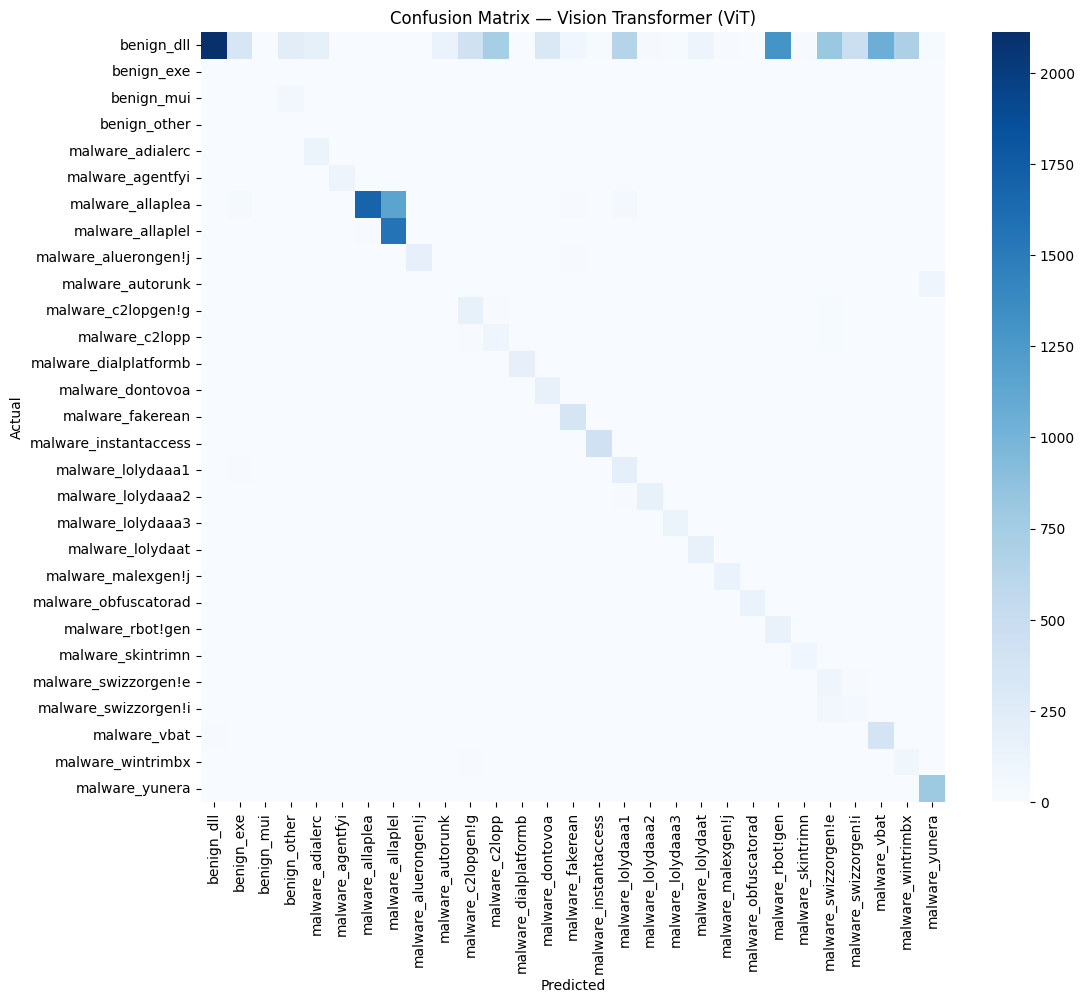

In [ ]:
evaluate_model(cnn_model, "Baseline CNN")
evaluate_model(mobilenet_model, "MobileNetV2")
evaluate_model(vit_model, "Vision Transformer (ViT)")


# Model Comparison Table

In [ ]:
results = []

for name, model in [
    ("CNN", cnn_model),
    ("MobileNetV2", mobilenet_model),
    ("ViT", vit_model)
]:
    loss, acc = model.evaluate(val_data_eval, verbose=0)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])

print("\n==== Model Comparison Table ====")
print(results_df.sort_values(by="Validation Accuracy", ascending=False))



==== Model Comparison Table ====
         Model  Validation Accuracy
1  MobileNetV2             0.965120
0          CNN             0.752668
2          ViT             0.508043
